# Relatório de Impacto

Consolida os resultados do pipeline de churn (NB04) e segmentação (NB05): métricas de negócio,
impacto financeiro e playbook de retenção acionável por perfil — simulando o caso de uso da NIO.

**Entrada:** `../data/processed/clientes_segmentados.parquet`  
**Saída:** `../data/processed/relatorio_final.parquet`

## 1. Importações e carregamento

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

CORES_CLUSTERS = {0: '#2E86AB', 1: '#E84855', 2: '#F6AE2D'}

ROOT = Path('..')
PROCESSED_DIR = ROOT / 'data/processed'
INTERM_DIR = ROOT / 'data/interm'
MODELS_DIR = ROOT / 'models'

clientes = pd.read_parquet(PROCESSED_DIR / 'clientes_segmentados.parquet')
base = pd.read_parquet(INTERM_DIR / 'base_consolidada.parquet')
artefato_churn = joblib.load(MODELS_DIR / 'modelo_churn.pkl')
artefato_kmeans = joblib.load(MODELS_DIR / 'kmeans_segmentacao.pkl')

metricas_modelo = artefato_churn['metricas_teste']
nome_modelo = artefato_churn['nome_modelo']
threshold = artefato_churn['threshold']

n_base = len(base)
n_risco = len(clientes)
n_clusters = clientes['cluster'].nunique()

print(f'Base total: {n_base:,} clientes | Em risco (flagged): {n_risco:,} ({n_risco / n_base * 100:.1f}%)')
print(f'Segmentos (K-Means): {n_clusters} | Modelo: {nome_modelo} | Threshold: {threshold:.3f}')
print(f'Churn real na base: {base["Churn"].mean() * 100:.1f}% | Entre flagged: {clientes["Churn"].mean() * 100:.1f}%')

Base total: 7,043 clientes | Em risco (flagged): 1,556 (22.1%)
Segmentos (K-Means): 3 | Modelo: XGBoost | Threshold: 0.795
Churn real na base: 26.5% | Entre flagged: 69.5%


## 2. Resumo executivo do pipeline

O projeto encadeia **classificação de churn → segmentação dos flagged → ações de retenção**:

| Etapa | Notebook | Resultado |
|-------|----------|-----------|
| Extração | NB01 | 7.043 clientes consolidados |
| EDA | NB02 | Drivers: contrato mensal, fibra, tenure curto |
| Features | NB03 | 47 features + split estratificado 80/20 |
| Churn | NB04 | Melhor modelo (RF/XGB/LGBM) com threshold calibrado |
| Segmentação | NB05 | K-Means K=3 sobre clientes em risco |
| Impacto | NB06 | Métricas de negócio + playbook comercial |

A inovação está em segmentar **somente clientes flagged pelo modelo**, direcionando recursos de retenção da NIO para quem o ML identificou como em risco.

## 3. Métricas do modelo de churn (hold-out)

,Métrica,Valor
0,Modelo,XGBoost
1,Threshold,0.795
2,Precision,0.664
3,Recall,0.540
4,F1,0.596
5,Accuracy,0.806
6,AUC-ROC,0.847


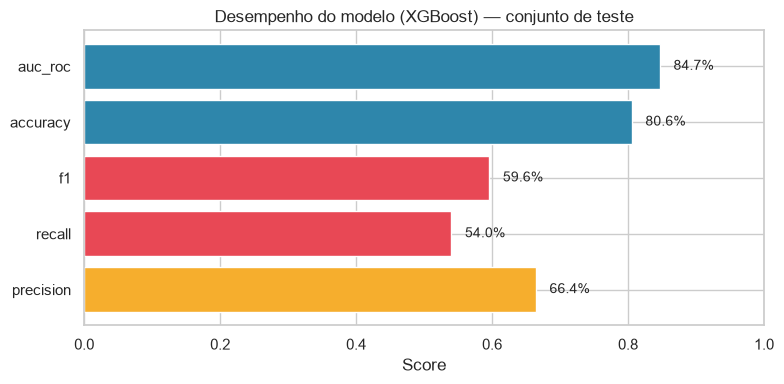

Clientes flagged para retenção: 1,556 (22.1% da base)
Probabilidade média entre flagged: 0.881


In [2]:
resumo_modelo = pd.DataFrame({
    'Métrica': ['Modelo', 'Threshold', 'Precision', 'Recall', 'F1', 'Accuracy', 'AUC-ROC'],
    'Valor': [
        nome_modelo,
        f'{threshold:.3f}',
        f"{metricas_modelo['precision']:.3f}",
        f"{metricas_modelo['recall']:.3f}",
        f"{metricas_modelo['f1']:.3f}",
        f"{metricas_modelo['accuracy']:.3f}",
        f"{metricas_modelo['auc_roc']:.3f}",
    ],
})

display(resumo_modelo)

fig, ax = plt.subplots(figsize=(8, 4))
metricas_plot = ['precision', 'recall', 'f1', 'accuracy']
labels_plot = ['precision', 'recall', 'f1', 'accuracy']
valores = [metricas_modelo[m] for m in metricas_plot]
valores.append(metricas_modelo['auc_roc'])
labels_plot.append('auc_roc')
cores = ['#2E86AB' if v >= 0.8 else '#F6AE2D' if v >= 0.6 else '#E84855' for v in valores]

ax.barh(labels_plot, valores, color=cores, edgecolor='white')
ax.set_xlim(0, 1)
ax.set_xlabel('Score')
ax.set_title(f'Desempenho do modelo ({nome_modelo}) — conjunto de teste')
for i, v in enumerate(valores):
    ax.text(v + 0.02, i, f'{v:.1%}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Clientes flagged para retenção: {n_risco:,} ({n_risco / n_base * 100:.1f}% da base)')
print(f'Probabilidade média entre flagged: {clientes["prob_churn"].mean():.3f}')

## 4. Métricas de negócio por cluster

In [3]:
def perfil_cluster(df: pd.DataFrame) -> pd.DataFrame:
    """Agrega métricas de negócio por cluster para o relatório final."""
    agg = df.groupby('cluster').agg(
        n_clientes=('customerID', 'count'),
        churn_rate=('Churn', 'mean'),
        prob_churn_media=('prob_churn', 'mean'),
        tenure_medio=('tenure_orig', 'mean'),
        receita_mensal_media=('MonthlyCharges_orig', 'mean'),
        receita_mensal_total=('MonthlyCharges_orig', 'sum'),
    ).reset_index()

    agg['pct_base_total'] = agg['n_clientes'] / n_base * 100
    agg['pct_clientes_risco'] = agg['n_clientes'] / n_risco * 100
    agg['receita_anual_projetada'] = agg['receita_mensal_total'] * 12
    agg['churn_rate'] = (agg['churn_rate'] * 100).round(1)
    agg['prob_churn_media'] = agg['prob_churn_media'].round(3)
    agg['tenure_medio'] = agg['tenure_medio'].round(1)
    agg['receita_mensal_media'] = agg['receita_mensal_media'].round(2)
    agg['receita_mensal_total'] = agg['receita_mensal_total'].round(2)
    agg['receita_anual_projetada'] = agg['receita_anual_projetada'].round(2)

    return agg.sort_values('cluster')


relatorio = perfil_cluster(clientes)

# Perfil operacional: contrato e internet predominantes
for col, nome in [('Contract', 'contrato_predominante'), ('InternetService', 'internet_predominante')]:
    moda = (
        clientes.groupby('cluster')[col]
        .agg(lambda s: s.value_counts().index[0])
        .reset_index(name=nome)
    )
    relatorio = relatorio.merge(moda, on='cluster')

# Flags de risco médias (quando disponíveis)
for flag in ['novo_cliente', 'fibra_sem_suporte', 'alto_valor']:
    if flag in clientes.columns:
        media_flag = clientes.groupby('cluster')[flag].mean().reset_index(name=f'{flag}_pct')
        media_flag[f'{flag}_pct'] = (media_flag[f'{flag}_pct'] * 100).round(1)
        relatorio = relatorio.merge(media_flag, on='cluster')

display(relatorio)

receita_total_risco = relatorio['receita_mensal_total'].sum()
receita_anual_risco = relatorio['receita_anual_projetada'].sum()
print(f'\nReceita mensal em risco (flagged): R$ {receita_total_risco:,.2f}')
print(f'Receita anual projetada em risco: R$ {receita_anual_risco:,.2f}')

,cluster,n_clientes,churn_rate,prob_churn_media,tenure_medio,receita_mensal_media,receita_mensal_total,pct_base_total,pct_clientes_risco,receita_anual_projetada,contrato_predominante,internet_predominante,fibra_sem_suporte_pct
0,0,241,65.6,0.850,2.7,42.47,10235.55,3.421837,15.488432,122826.6,Month-to-month,DSL,0.0
1,1,427,66.5,0.848,26.7,94.54,40369.85,6.062757,27.442159,484438.2,Month-to-month,Fiber optic,85.9
2,2,888,72.1,0.905,4.8,81.93,72756.45,12.608264,57.069409,873077.4,Month-to-month,Fiber optic,91.8



Receita mensal em risco (flagged): R$ 123,361.85
Receita anual projetada em risco: R$ 1,480,342.20


## 5. Visualizações de impacto financeiro

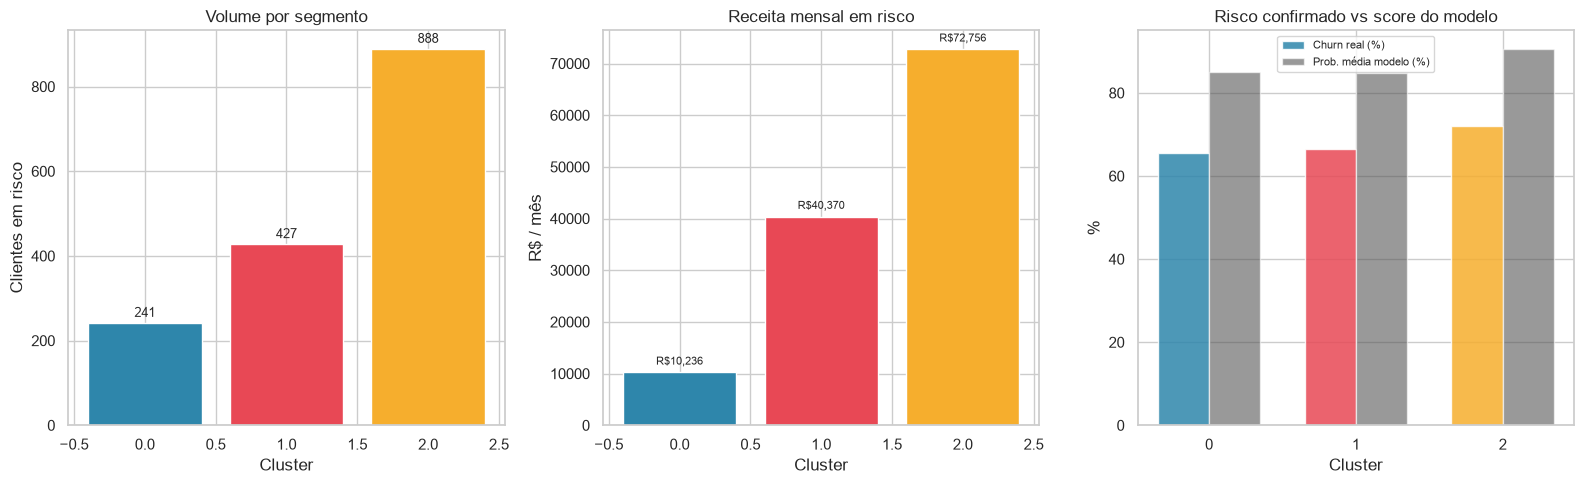

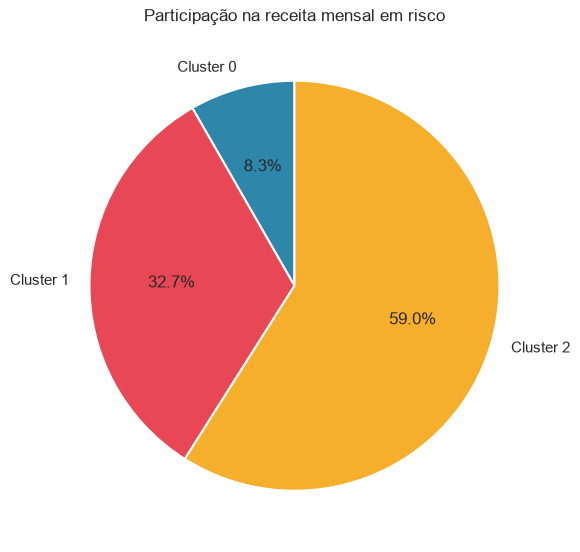

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

clusters = relatorio['cluster'].tolist()
cores = [CORES_CLUSTERS[c] for c in clusters]

# Clientes por cluster
axes[0].bar(clusters, relatorio['n_clientes'], color=cores, edgecolor='white')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Clientes em risco')
axes[0].set_title('Volume por segmento')
for i, v in enumerate(relatorio['n_clientes']):
    axes[0].text(i, v + 15, f'{v:,}', ha='center', fontsize=9)

# Receita mensal em risco
axes[1].bar(clusters, relatorio['receita_mensal_total'], color=cores, edgecolor='white')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('R$ / mês')
axes[1].set_title('Receita mensal em risco')
for i, v in enumerate(relatorio['receita_mensal_total']):
    axes[1].text(i, v + 1500, f'R${v:,.0f}', ha='center', fontsize=8)

# Churn rate real vs probabilidade média do modelo
x = np.arange(len(clusters))
w = 0.35
axes[2].bar(x - w / 2, relatorio['churn_rate'], width=w, label='Churn real (%)', color=cores, alpha=0.85)
axes[2].bar(x + w / 2, relatorio['prob_churn_media'] * 100, width=w,
            label='Prob. média modelo (%)', color='#555555', alpha=0.6)
axes[2].set_xticks(x)
axes[2].set_xticklabels(clusters)
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('%')
axes[2].set_title('Risco confirmado vs score do modelo')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Participação na receita em risco
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    relatorio['receita_mensal_total'],
    labels=[f'Cluster {c}' for c in clusters],
    autopct='%1.1f%%',
    colors=cores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
ax.set_title('Participação na receita mensal em risco')
plt.tight_layout()
plt.show()

## 6. Playbook de retenção por perfil (NIO)

Com base nos perfis identificados no NB05, cada cluster recebe uma estratégia diferenciada — alinhada ao objetivo de **retenção eficiente** (priorizar quem gera mais receita e quem responde melhor à intervenção).

In [5]:
PLAYBOOK = {
    0: {
        'nome_perfil': 'Novos DSL — baixa fatura',
        'prioridade': 'Média',
        'resumo': (
            'Clientes recentes (tenure ~3 meses), internet DSL e fatura baixa (~R$ 43). '
            'Contrato predominantemente mensal; alto índice de novos clientes.'
        ),
        'estrategia': (
            'Programa de onboarding proativo: contato em D+7 e D+30, tutorial de self-service, '
            'oferta de upgrade gradual para plano anual com desconto de 10%. '
            'Canal preferencial: WhatsApp + e-mail automatizado (custo baixo).'
        ),
        'kpi_sugerido': 'Taxa de conversão para contrato anual em 60 dias',
    },
    1: {
        'nome_perfil': 'Veteranos fibra — alta fatura',
        'prioridade': 'Alta',
        'resumo': (
            'Clientes de longa data (tenure ~27 meses), fibra óptica e fatura elevada (~R$ 95). '
            'Muitos sem suporte técnico contratado — risco de insatisfação silenciosa.'
        ),
        'estrategia': (
            'Retenção consultiva: gerente de conta liga em até 48h, bundle Tech Support + '
            'Online Security gratuito por 3 meses, migração para contrato anual com desconto fixo. '
            'Canal: telefone humano (LTV alto justifica custo).'
        ),
        'kpi_sugerido': 'Retenção em 90 dias + upsell de suporte técnico',
    },
    2: {
        'nome_perfil': 'Novos fibra — maior risco',
        'prioridade': 'Crítica',
        'resumo': (
            'Maior cluster (57% dos flagged), tenure curto (~5 meses), fibra e fatura média-alta (~R$ 82). '
            'Maior churn rate real (~72%) e probabilidade média do modelo (~0,90).'
        ),
        'estrategia': (
            'Campanha prioritária: ligação + SMS em 24h, diagnóstico de qualidade de sinal, '
            'desconto de 15% por 6 meses condicionado a contrato anual, instalação gratuita de extensor Wi-Fi. '
            'Canal: outbound imediato + visita técnica se necessário.'
        ),
        'kpi_sugerido': 'Redução de churn em 30 dias + NPS pós-contato',
    },
}

for cluster_id, info in PLAYBOOK.items():
    row = relatorio[relatorio['cluster'] == cluster_id].iloc[0]
    print('=' * 70)
    print(f"CLUSTER {cluster_id} — {info['nome_perfil']}  |  Prioridade: {info['prioridade']}")
    print(f"  Clientes: {row['n_clientes']:,} ({row['pct_clientes_risco']:.1f}% dos flagged)")
    print(f"  Receita mensal em risco: R$ {row['receita_mensal_total']:,.2f} "
          f"({row['receita_mensal_total'] / receita_total_risco * 100:.1f}% do total)")
    print(f"  Churn real: {row['churn_rate']:.1f}% | Tenure médio: {row['tenure_medio']:.1f} meses")
    print(f"\n  Perfil: {info['resumo']}")
    print(f"\n  Ação NIO: {info['estrategia']}")
    print(f"  KPI: {info['kpi_sugerido']}")
    print()

CLUSTER 0 — Novos DSL — baixa fatura  |  Prioridade: Média
  Clientes: 241 (15.5% dos flagged)
  Receita mensal em risco: R$ 10,235.55 (8.3% do total)
  Churn real: 65.6% | Tenure médio: 2.7 meses

  Perfil: Clientes recentes (tenure ~3 meses), internet DSL e fatura baixa (~R$ 43). Contrato predominantemente mensal; alto índice de novos clientes.

  Ação NIO: Programa de onboarding proativo: contato em D+7 e D+30, tutorial de self-service, oferta de upgrade gradual para plano anual com desconto de 10%. Canal preferencial: WhatsApp + e-mail automatizado (custo baixo).
  KPI: Taxa de conversão para contrato anual em 60 dias

CLUSTER 1 — Veteranos fibra — alta fatura  |  Prioridade: Alta
  Clientes: 427 (27.4% dos flagged)
  Receita mensal em risco: R$ 40,369.85 (32.7% do total)
  Churn real: 66.5% | Tenure médio: 26.7 meses

  Perfil: Clientes de longa data (tenure ~27 meses), fibra óptica e fatura elevada (~R$ 95). Muitos sem suporte técnico contratado — risco de insatisfação silenciosa

## 7. Consolidação e exportação

Exporta tabela resumo por cluster com métricas de negócio, metadados do modelo e estratégia de retenção recomendada.

In [6]:
relatorio_final = relatorio.copy()

for cluster_id, info in PLAYBOOK.items():
    mask = relatorio_final['cluster'] == cluster_id
    relatorio_final.loc[mask, 'nome_perfil'] = info['nome_perfil']
    relatorio_final.loc[mask, 'prioridade'] = info['prioridade']
    relatorio_final.loc[mask, 'estrategia_retencao'] = info['estrategia']
    relatorio_final.loc[mask, 'kpi_sugerido'] = info['kpi_sugerido']

# Metadados globais do pipeline (mesmas colunas em todas as linhas)
relatorio_final['modelo_churn'] = nome_modelo
relatorio_final['threshold_modelo'] = threshold
relatorio_final['precision_modelo'] = metricas_modelo['precision']
relatorio_final['recall_modelo'] = metricas_modelo['recall']
relatorio_final['f1_modelo'] = metricas_modelo['f1']
relatorio_final['accuracy_modelo'] = metricas_modelo['accuracy']
relatorio_final['auc_modelo'] = metricas_modelo['auc_roc']
relatorio_final['n_base_total'] = n_base
relatorio_final['n_clientes_risco_total'] = n_risco
relatorio_final['receita_mensal_risco_total'] = receita_total_risco
relatorio_final['kmeans_k'] = artefato_kmeans['n_clusters']

output_path = PROCESSED_DIR / 'relatorio_final.parquet'
relatorio_final.to_parquet(output_path, index=False)

print(f'Relatório exportado: {output_path.resolve()}')
print(f'Shape: {relatorio_final.shape}')
display(relatorio_final[[
    'cluster', 'nome_perfil', 'prioridade', 'n_clientes', 'churn_rate',
    'receita_mensal_total', 'receita_anual_projetada', 'estrategia_retencao',
]])

Relatório exportado: C:\Users\matheus\workspace\utfpr\projeto_integrador\data\processed\relatorio_final.parquet
Shape: (3, 28)


,cluster,nome_perfil,prioridade,n_clientes,churn_rate,receita_mensal_total,receita_anual_projetada,estrategia_retencao
0,0,Novos DSL — baixa fatura,Média,241,65.6,10235.55,122826.6,Programa de onboarding proativo: contato em D+...
1,1,Veteranos fibra — alta fatura,Alta,427,66.5,40369.85,484438.2,Retenção consultiva: gerente de conta liga em ...
2,2,Novos fibra — maior risco,Crítica,888,72.1,72756.45,873077.4,"Campanha prioritária: ligação + SMS em 24h, di..."


## 8. Conclusões

1. **Modelo de churn** sinaliza 1.556 clientes (22,1% da base) como em risco, com precisão de 66,4% e acurácia de 80,6% no hold-out — cerca de 2,5x a taxa base de 26,5%, adequado para campanhas de retenção onde o contato falso positivo tem custo operacional.
2. **Meta de F1 não atingida** (59,6% contra os 80% planejados): a fronteira F1 × acurácia mostra teto de ~63% de F1 nesta base, que não possui atributos de consumo, atendimento ou qualidade de serviço. Ganhos adicionais dependem de enriquecimento dos dados, não de ajuste do modelo.
3. **Segmentação K=3** separa perfis acionáveis: novos DSL (241 clientes, ticket baixo), veteranos fibra (427 clientes, LTV alto) e novos fibra (888 clientes, maior risco).
4. **Cluster 2 concentra 59,0% da receita mensal em risco** (R$ 72.756,45 de R$ 123.361,85) e deve receber prioridade máxima de outbound da NIO.
5. **Cluster 1** exige abordagem consultiva de alto toque: 27,4% dos sinalizados, mas 32,7% da receita exposta e a maior fatura média (R$ 94,54).
6. **SHAP** confirma que as features derivadas dominam a predição: `charges_x_contrato_mensal` e `score_risco_estendido` lideram a importância média absoluta, validando a engenharia de atributos do NB03.
7. O artefato `relatorio_final.parquet` pode alimentar dashboards ou CRM com metas e ações por segmento.